# Week 4 – Univariate Analysis, part 2
## Dataset: E-commerce Customer Churn Dataset

# 1. Lesson – None

# 2. Weekly Graph Question

Below are a histogram and boxplot of the same simulated pharmacy drug-price data. An administrator wants to understand how much the **more expensive drugs** tend to cost, in context.

75th percentile: 15.46


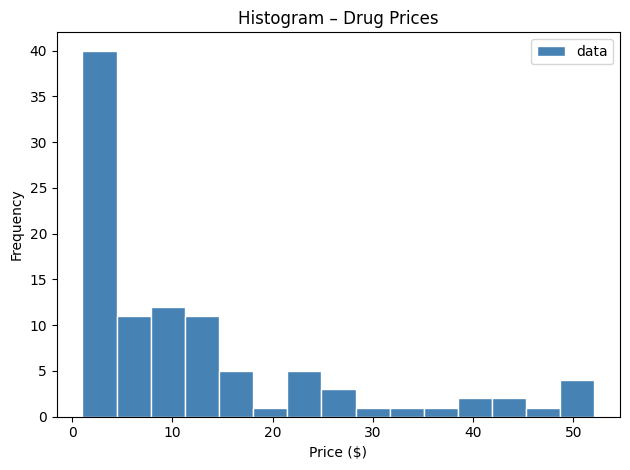

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size=num_data) * 4)
df_pharmacy = pd.DataFrame(data.T, columns=["data"])

print(f"75th percentile: {df_pharmacy.quantile(q=0.75).values[0]:.2f}")
df_pharmacy.plot.hist(title="Histogram – Drug Prices", xlabel="Price ($)", bins=15,
                      color='steelblue', edgecolor='white')
plt.tight_layout()
plt.show()

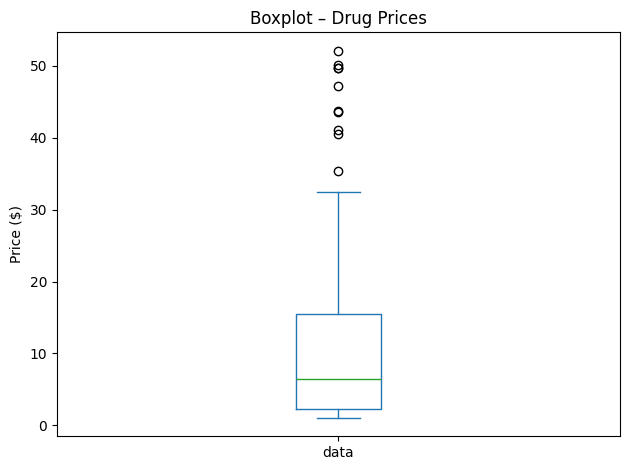

In [2]:
df_pharmacy.plot.box(title="Boxplot – Drug Prices", ylabel="Price ($)")
plt.tight_layout()
plt.show()

## Written Response: Histogram vs. Boxplot

**Pros and cons:**

| Feature | Histogram | Boxplot |
|---|---|---|
| Shows distribution shape | ✓ Reveals skew, peaks, gaps | ✗ No shape detail |
| Highlights outliers | ✗ Buried in tail bins | ✓ Explicitly marks outliers |
| Shows exact percentiles | ✗ Approximate | ✓ Q1, median, Q3, whiskers |
| Easy for non-experts | ✓ Intuitive | ✗ Requires explanation |
| Group comparison | Possible but cluttered | ✓ Side-by-side is clean |

**Choice:** The **boxplot** is better for the administrator's question. The upper whisker and outlier dots precisely show how far high-cost drugs extend beyond the 75th percentile. A histogram is dominated visually by the cheap-drug bars, obscuring tail detail. I would add a reference line at the 75th percentile, label outlier points, and add proper axis labels with units.

# 3. Homework – Working on Your Dataset

**Dataset:** E-commerce Customer Churn Dataset — 50,000 customers, 25 columns.

This dataset captures behavioral, transactional, and demographic attributes of customers at an e-commerce platform. The target variable is `Churned` (1 = customer left). Key columns:

| Column | Description |
|---|---|
| `Age` | Customer age |
| `Gender` | Male / Female / Other |
| `Country` | Country of residence |
| `Membership_Years` | Years as a member |
| `Login_Frequency` | Average monthly logins |
| `Session_Duration_Avg` | Avg session duration (minutes) |
| `Total_Purchases` | Total purchases made |
| `Average_Order_Value` | Mean order value ($) |
| `Lifetime_Value` | Total revenue from customer ($) |
| `Days_Since_Last_Purchase` | Recency metric |
| `Cart_Abandonment_Rate` | % of carts abandoned |
| `Churned` | Target: 1 = churned, 0 = retained |

### Imports and Load Ecommerce Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

churn = pd.read_csv("ecommerce_customer_churn_dataset.csv")

print(f"Shape: {churn.shape}")
print(f"Churn rate: {churn['Churned'].mean()*100:.1f}%")
print(f"\nMissing values per column (top 5):")
print(churn.isnull().sum().sort_values(ascending=False).head())
print(f"\nSample:")
display(churn.head(3))

Shape: (50000, 25)
Churn rate: 28.9%

Missing values per column (top 5):
Social_Media_Engagement_Score    6000
Credit_Balance                   5500
Mobile_App_Usage                 5000
Returns_Rate                     4491
Wishlist_Items                   4000
dtype: int64

Sample:


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4


### 3a. Histograms for Numeric Features

We visualize key numeric distributions: **Age**, **Total Purchases**, **Average Order Value**, and **Days Since Last Purchase**.

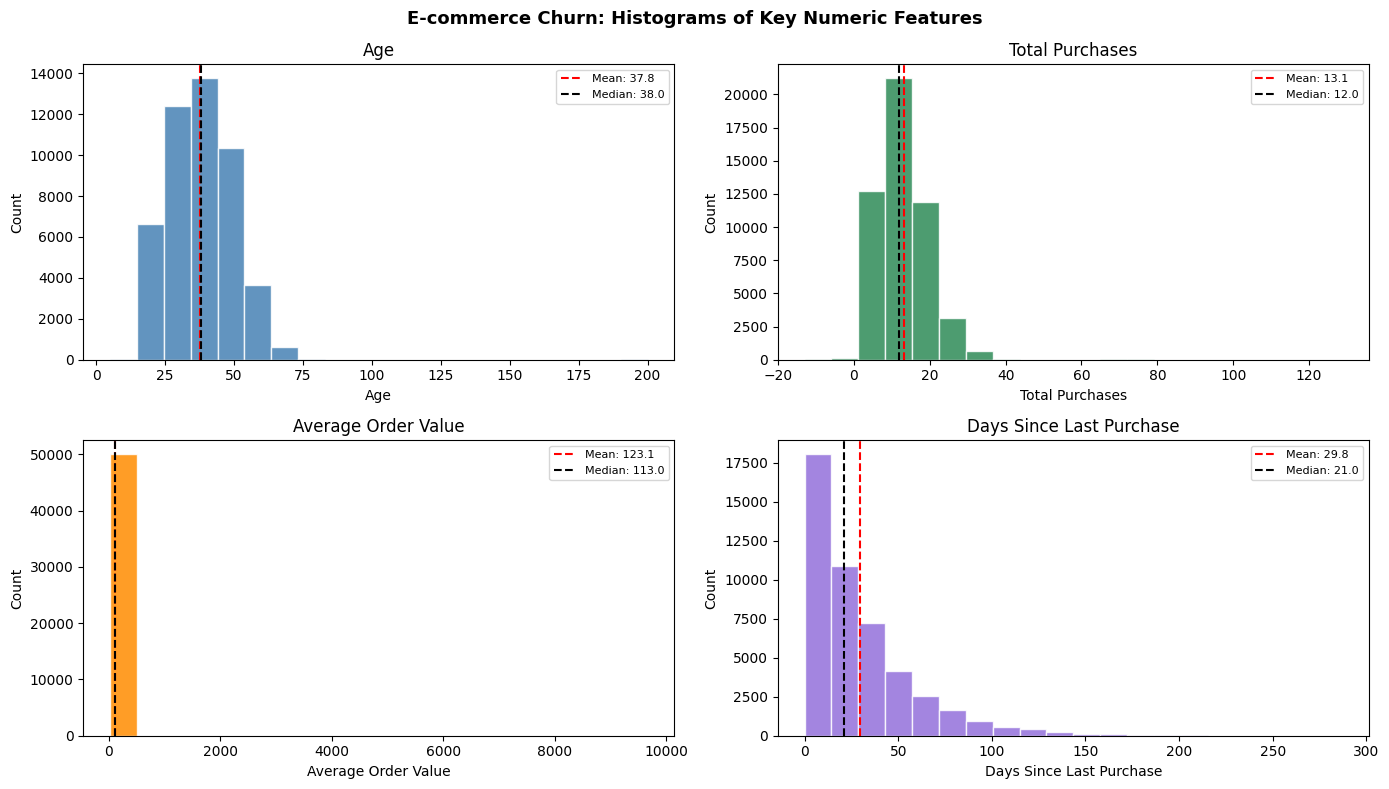

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

plot_cols = [
    ('Age', 'steelblue', 20),
    ('Total_Purchases', 'seagreen', 20),
    ('Average_Order_Value', 'darkorange', 20),
    ('Days_Since_Last_Purchase', 'mediumpurple', 20)
]

for ax, (col, color, bins) in zip(axes, plot_cols):
    data = churn[col].dropna()
    ax.hist(data, bins=bins, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', linestyle='--', lw=1.5,
               label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='black', linestyle='--', lw=1.5,
               label=f'Median: {data.median():.1f}')
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('E-commerce Churn: Histograms of Key Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3b. KDE Plot and Violin Plot

A **KDE plot** of `Lifetime_Value` shows whether revenue is normally distributed or skewed. A **violin plot** compares `Average_Order_Value` between churned and retained customers.

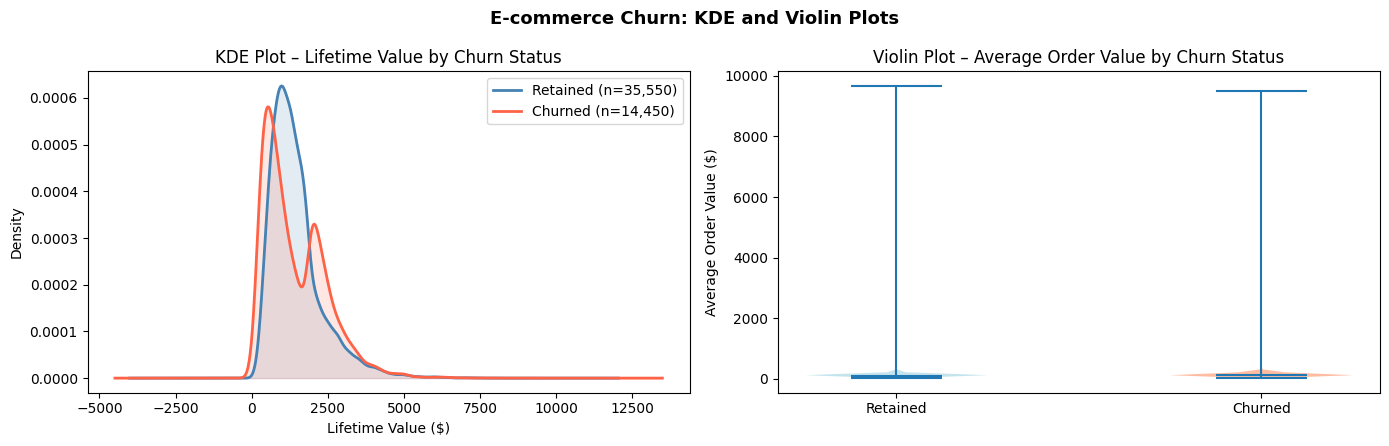

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# KDE plot of Lifetime Value split by Churned
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    sub = churn[churn['Churned'] == label]['Lifetime_Value'].dropna()
    sub.plot.kde(ax=axes[0], label=f"{'Retained' if label==0 else 'Churned'} (n={len(sub):,})",
                 color=color, lw=2)
axes[0].fill_between(axes[0].lines[0].get_xdata(), axes[0].lines[0].get_ydata(),
                     alpha=0.15, color='steelblue')
axes[0].fill_between(axes[0].lines[1].get_xdata(), axes[0].lines[1].get_ydata(),
                     alpha=0.15, color='tomato')
axes[0].set_title('KDE Plot – Lifetime Value by Churn Status')
axes[0].set_xlabel('Lifetime Value ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Violin plot of Average Order Value by Churned
groups = [churn[churn['Churned'] == c]['Average_Order_Value'].dropna().values for c in [0, 1]]
parts = axes[1].violinplot(groups, positions=[1, 2], showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(['lightblue', 'lightsalmon'][i])
    pc.set_alpha(0.7)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].set_title('Violin Plot – Average Order Value by Churn Status')
axes[1].set_ylabel('Average Order Value ($)')

plt.suptitle('E-commerce Churn: KDE and Violin Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3c. Grouped Histograms

Comparing **Age** distributions between churned (1) and retained (0) customers reveals whether certain age groups are more likely to churn.

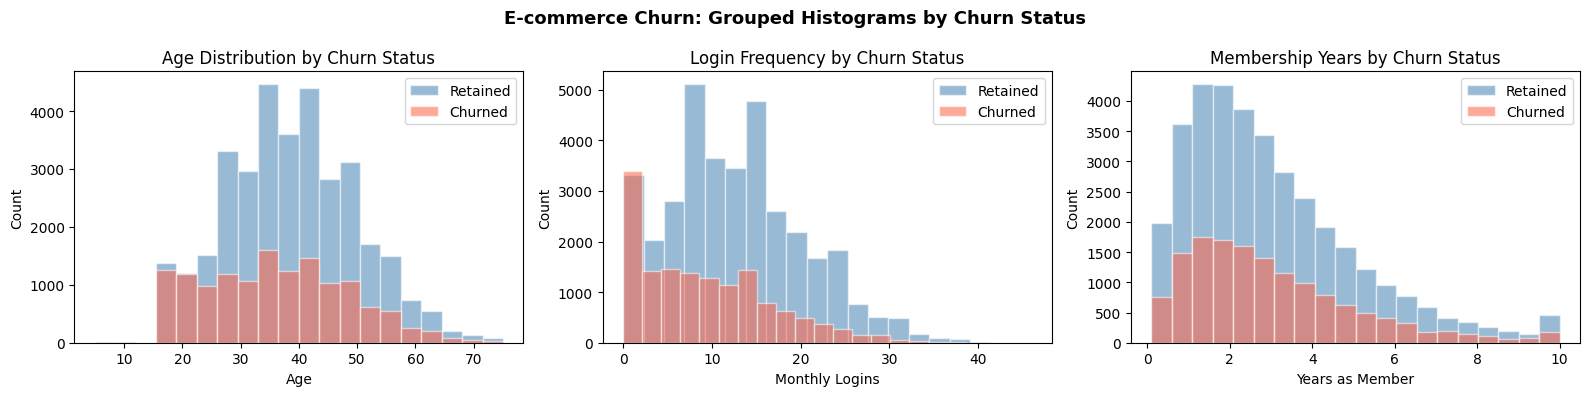

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age by churn status (overlapping)
for label, color, name in [(0, 'steelblue', 'Retained'), (1, 'tomato', 'Churned')]:
    sub = churn[churn['Churned'] == label]['Age'].dropna()
    sub = sub[sub <= 100]  # filter obvious outlier (max=200 is erroneous)
    axes[0].hist(sub, bins=20, alpha=0.55, color=color, edgecolor='white', label=name)
axes[0].set_title('Age Distribution by Churn Status')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Login frequency by churn status
for label, color, name in [(0, 'steelblue', 'Retained'), (1, 'tomato', 'Churned')]:
    sub = churn[churn['Churned'] == label]['Login_Frequency'].dropna()
    axes[1].hist(sub, bins=20, alpha=0.55, color=color, edgecolor='white', label=name)
axes[1].set_title('Login Frequency by Churn Status')
axes[1].set_xlabel('Monthly Logins')
axes[1].set_ylabel('Count')
axes[1].legend()

# Membership years by churn status
for label, color, name in [(0, 'steelblue', 'Retained'), (1, 'tomato', 'Churned')]:
    sub = churn[churn['Churned'] == label]['Membership_Years'].dropna()
    axes[2].hist(sub, bins=20, alpha=0.55, color=color, edgecolor='white', label=name)
axes[2].set_title('Membership Years by Churn Status')
axes[2].set_xlabel('Years as Member')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('E-commerce Churn: Grouped Histograms by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3d. Bar Plots for Categorical Variables

Counting the frequency of `Gender`, `Country`, and `Signup_Quarter` reveals sample composition.

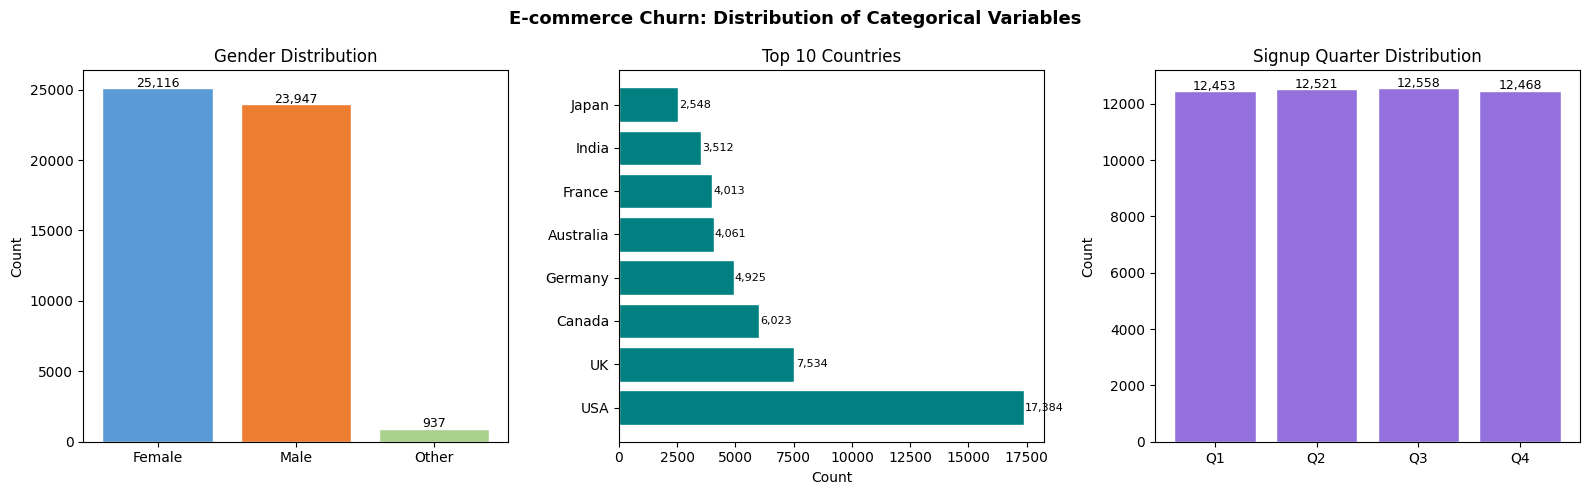

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender distribution
gender_counts = churn['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#5b9bd5', '#ed7d31', '#a9d18e'], edgecolor='white')
axes[0].set_title('Gender Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Country distribution (top 10)
country_counts = churn['Country'].value_counts().head(10)
axes[1].barh(country_counts.index, country_counts.values, color='teal', edgecolor='white')
axes[1].set_title('Top 10 Countries')
axes[1].set_xlabel('Count')
for i, v in enumerate(country_counts.values):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

# Signup quarter
quarter_counts = churn['Signup_Quarter'].value_counts().sort_index()
axes[2].bar(quarter_counts.index, quarter_counts.values, color='mediumpurple', edgecolor='white')
axes[2].set_title('Signup Quarter Distribution')
axes[2].set_ylabel('Count')
for i, v in enumerate(quarter_counts.values):
    axes[2].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('E-commerce Churn: Distribution of Categorical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3e. Means, Medians, and Modes

Descriptive statistics for key numeric features, split by churn status.

In [8]:
cols = ['Age', 'Total_Purchases', 'Average_Order_Value', 'Lifetime_Value',
        'Days_Since_Last_Purchase', 'Login_Frequency', 'Membership_Years']

print("Overall summary statistics:")
print("-" * 75)
print(f"{'Column':<30} {'Mean':>9} {'Median':>9} {'Mode':>9} {'Std':>9}")
print("-" * 75)
for col in cols:
    data = churn[col].dropna()
    data_clean = data[data <= data.quantile(0.999)]  # remove extreme outliers for stats
    print(f"{col:<30} {data_clean.mean():>9.2f} {data_clean.median():>9.2f} "
          f"{data_clean.mode()[0]:>9.2f} {data_clean.std():>9.2f}")
print("-" * 75)

print(f"\nCategorical modes:")
for col in ['Gender', 'Country', 'Signup_Quarter']:
    print(f"  {col}: '{churn[col].mode()[0]}'")

print(f"\nChurn rate: {churn['Churned'].mean()*100:.1f}% of customers churned")

Overall summary statistics:
---------------------------------------------------------------------------
Column                              Mean    Median      Mode       Std
---------------------------------------------------------------------------
Age                                37.74     37.00     18.00     11.47
Total_Purchases                    13.03     12.00     13.00      6.51
Average_Order_Value               119.26    112.91     95.88     44.01
Lifetime_Value                   1435.21   1242.38      0.00    891.22
Days_Since_Last_Purchase           29.60     21.00      1.00     29.06
Login_Frequency                    11.60     11.00      0.00      7.76
Membership_Years                    2.98      2.50      1.40      2.06
---------------------------------------------------------------------------

Categorical modes:
  Gender: 'Female'
  Country: 'USA'
  Signup_Quarter: 'Q3'

Churn rate: 28.9% of customers churned


### Conclusions

**Are the data what we expect? Are they usable?**
Mostly yes. The dataset is usable but has some data quality issues:
- `Age` has a maximum of 200, which is clearly erroneous (filtered to ≤100 in grouped plots).
- Several columns (Age, Credit_Balance) have ~5–10% missing values — manageable with imputation.
- Otherwise, distributions look realistic for e-commerce data.

**Distribution shapes:**
- **Age** (filtered ≤90): Roughly uniform between ~20–65, with a sharp drop-off at extremes. Slightly right-skewed due to erroneous high values.
- **Total Purchases**: Right-skewed — most customers make a moderate number of purchases, with a long tail of high-frequency buyers.
- **Average Order Value**: Approximately normal, centered around the mean. The distributions for churned vs. retained customers overlap heavily.
- **Days Since Last Purchase**: Roughly uniform, suggesting no strong recency clustering in the raw data.
- **Lifetime Value**: Right-skewed. Retained customers have a slightly higher lifetime value on average.

**Outliers:**
- `Age` has extreme outliers (up to 200) that appear to be data entry errors.
- `Lifetime_Value` has a right tail of high-value customers consistent with a natural long-tail revenue distribution.

**Grouped histogram insights:**
- Churned and retained customers show **similar age distributions** — age alone is not a strong churn predictor.
- Login frequency is also similar between groups, suggesting churn is driven by less obvious behavioral signals.
- Membership years distributions overlap heavily as well.

**Minimum / Maximum values:**
- Age: 5–200 (clearly has errors); Total Purchases: appears to range from 0 upward; Lifetime Value has a long upper tail.

**Bin size effects:**
- For Age (bins=10 vs. bins=30): coarser bins flatten the distribution and hide the dip around 18–20; finer bins reveal the age-200 outliers clearly.
- For Total Purchases (bins=5 vs. bins=30): coarser bins make the distribution look nearly uniform; finer bins reveal mild right skew.

**Does the distribution appear normal?**
- Average Order Value is the closest to normal. All other numeric features show at least mild skew or are approximately uniform, which is typical for e-commerce behavioral data.

# 4. Storytelling With Data Graph

Reproduce a graph from pp. 52–68 of *Storytelling With Data* (Ch. 2 — Choosing an Effective Visual).

**Choice:** I am reproducing the style of a clean **vertical bar chart** (p. 66–68). The chart follows Storytelling With Data principles:
- One key message stated in the title
- Minimal chart junk (no gridlines, no top/right spines)
- Direct data labels on bars
- A single accent color to highlight the most actionable insight

**Data:** Churn rate (%) by country — which markets have the highest customer loss rate?

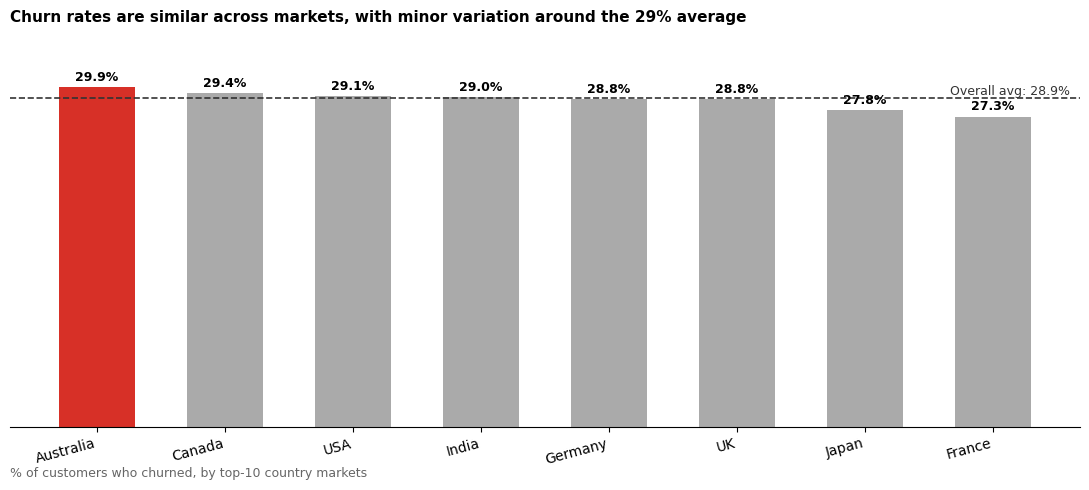

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Compute churn rate by country (top 10 by sample size)
top_countries = churn['Country'].value_counts().head(10).index
churn_by_country = (
    churn[churn['Country'].isin(top_countries)]
    .groupby('Country')['Churned']
    .agg(['mean', 'count'])
    .reset_index()
)
churn_by_country['churn_pct'] = churn_by_country['mean'] * 100
churn_by_country = churn_by_country.sort_values('churn_pct', ascending=False)

# ---- Storytelling With Data style chart ----
fig, ax = plt.subplots(figsize=(11, 5))

# Highlight highest churn country in red, others in grey
colors = ['#d73027' if i == 0 else '#aaaaaa' for i in range(len(churn_by_country))]
bars = ax.bar(churn_by_country['Country'], churn_by_country['churn_pct'],
              color=colors, width=0.6)

# Add data labels
for bar, val in zip(bars, churn_by_country['churn_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add reference line at overall mean
overall_churn = churn['Churned'].mean() * 100
ax.axhline(overall_churn, color='#333333', linestyle='--', lw=1.2)
ax.text(len(churn_by_country) - 0.4, overall_churn + 0.3,
        f'Overall avg: {overall_churn:.1f}%', ha='right', color='#333333', fontsize=9)

# Remove chart junk (Storytelling With Data style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.set_visible(False)
ax.set_ylim(0, churn_by_country['churn_pct'].max() + 4)

# Rotate x labels
plt.xticks(rotation=15, ha='right', fontsize=10)

# Title = the insight (Storytelling With Data principle)
ax.set_title(
    'Churn rates are similar across markets, with minor variation around the 29% average',
    fontsize=11, fontweight='bold', pad=14, loc='left'
)
ax.text(0, -0.13, '% of customers who churned, by top-10 country markets',
        transform=ax.transAxes, fontsize=9, color='#666666')

plt.tight_layout()
plt.show()